# Visualisation des Datas et Résultats du réseau de diffusion.

## Verification du Dataset
On cherche ici a verifier que les images sont bien visuellement conforme a ce qui a été montré dans le notebook [VisualisationSim](VisualisationSim.ipynb), mais également la repartition des pixels.

In [23]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

import sys
from pathlib import Path

# Ajoute la racine du projet
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from lib.diffusion_lib.DDPM import DDPM
from lib.diffusion_lib.UNet import UNet

In [24]:
# Paths (ajuster si besoin)
DATA_ROOT = "../data/RT28"  # ou data/MNIST
TRAIN_PT = os.path.join(DATA_ROOT, "processed", "training.pt")
TEST_PT = os.path.join(DATA_ROOT, "processed", "test.pt")
VAL_PT = os.path.join(DATA_ROOT, "processed", "validation.pt")

In [25]:
def load_pt_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    loaded = torch.load(path)
    return loaded

def show_grid(images, n=16, cols=4, cmap="gray", seed=None, save=False, save_path="grid.png"):
    rows = int(np.ceil(n / cols))
    rng = np.random.default_rng(seed)
    total = images.shape[0]
    n = min(n, total)
    indices = rng.choice(total, size=n, replace=False)
    plt.figure(figsize=(cols * 2.2, rows * 2.2))
    for i, idx in enumerate(indices):
        ax = plt.subplot(rows, cols, i + 1)
        img = images[idx].numpy() if torch.is_tensor(images) else images[idx]
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]
        ax.imshow(img, cmap=cmap)
        ax.set_title(f"idx={idx}")
        ax.axis("off")
    plt.tight_layout()
    
    if save:
        plt.savefig(save_path)

    plt.show()
    

In [26]:
train_images = load_pt_dataset(TRAIN_PT)
test_images = load_pt_dataset(TEST_PT)

print("Train images", train_images.shape, train_images.dtype)
print("Test images", test_images.shape, test_images.dtype)

Train images torch.Size([2611, 28, 28]) torch.uint8
Test images torch.Size([327, 28, 28]) torch.uint8


In [27]:
print("saturation bas:", (train_images <= 0).float().mean().item())
print("saturation haut:", (train_images >= 1).float().mean().item())

saturation bas: 0.4017515182495117
saturation haut: 0.5982484817504883


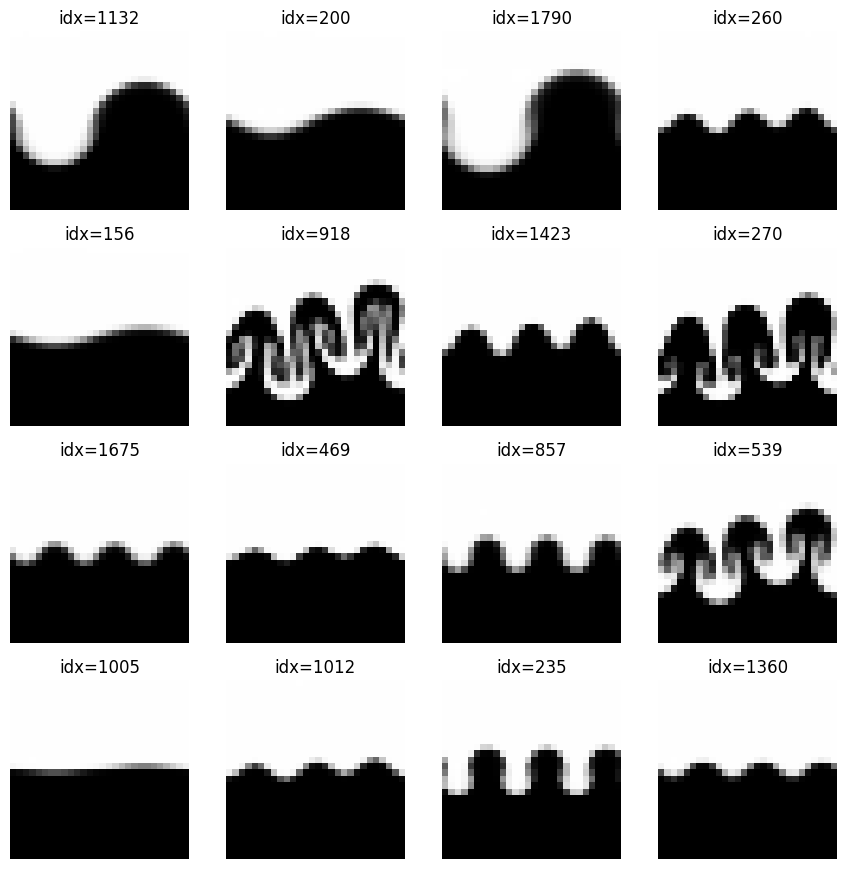

In [28]:
show_grid(train_images, n=16, cols=4, save=True, save_path="original.png")

## Infomration sur l'entrainement

In [29]:
def plot_loss_curve(csv_path):
    data = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    if "epoch" not in data.dtype.names or "train_loss" not in data.dtype.names:
        raise ValueError("Le CSV doit contenir les colonnes 'epoch' et 'loss'.")

    epochs = data["epoch"]
    loss = data["train_loss"]
    validation_loss = data["val_loss"] if "val_loss" in data.dtype.names else None
    best_loss = data["best_loss"] if "best_loss" in data.dtype.names else None

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(epochs, loss, label="loss")
    if validation_loss is not None:
        ax[0].plot(epochs, validation_loss, label="validation_loss", alpha=0.8)
    if best_loss is not None:
        ax[0].plot(epochs, best_loss, label="best_loss", alpha=0.8)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("RT28 loss")
    ax[0].legend()

    eps = 1e-12
    ax[1].plot(epochs, np.log(np.clip(loss, eps, None)), label="log(loss)")
    if validation_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(validation_loss, eps, None)), label="log(validation_loss)", alpha=0.8)
    if best_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(best_loss, eps, None)), label="log(best_loss)", alpha=0.8)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Log loss")
    ax[1].set_title("RT28 log loss")
    ax[1].legend()

    fig.tight_layout()
    plt.show()

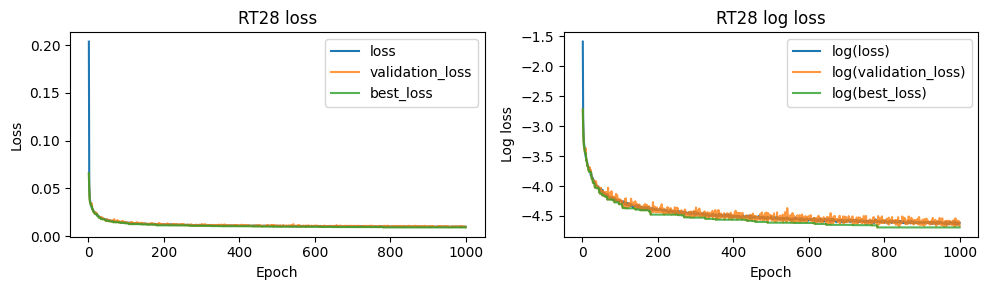

In [30]:
csv_path = "res/RT28-n1000.csv"
plot_loss_curve(csv_path)

## Visualisation des résultats

In [31]:
MODEL_PT = "res/RT28-n1000.pt"
DEVICE = "cpu"

# Ajuster ces hyperparametres si le modele a ete entraine avec d'autres valeurs
N_STEPS = 1000
TIME_EMB_DIM = 100
MIN_BETA = 1e-4
MAX_BETA = 0.02

In [32]:
state = torch.load(MODEL_PT, map_location=DEVICE)
if isinstance(state, dict) and not hasattr(state, "image_chw"):
    ddpm = DDPM(
        UNet(n_steps=N_STEPS, time_emb_dim=TIME_EMB_DIM),
        n_steps=N_STEPS,
        min_beta=MIN_BETA,
        max_beta=MAX_BETA,
        device=DEVICE,
    )
    ddpm.load_state_dict(state)
else:
    ddpm = state

if hasattr(ddpm, "to"):
    ddpm = ddpm.to(DEVICE)
ddpm.eval(); # Le ; est pour éviter un warning de PyTorch sur le mode evaluation

In [33]:
def load_pt_results(ddpm, device, n_samples=8):
    """
    Permet de générer des images à partir d'un modèle DDPM et de les retourner sous forme de tenseur.

    Args:
        ddpm: Modèle DDPM utilisé pour la génération.
        device: Périphérique sur lequel générer les images.
        n_samples (int, optional): Nombre d'images a generer. Par défaut à 8.
    """

    # On génère pas à pas et on snapshote a t finale.
    c, h, w = ddpm.image_chw
    x = torch.randn(n_samples, c, h, w).to(device)

    with torch.no_grad():
        for idx, t in enumerate(list(range(ddpm.n_steps))[::-1]):
            time_tensor = (torch.ones(n_samples, 1) * t).to(device).long()
            eta_theta = ddpm.backward(x, time_tensor)
            alpha_t, alpha_t_bar = ddpm.alphas[t], ddpm.alpha_bars[t]
            x = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta)
            if t > 0:
                x = x + ddpm.betas[t].sqrt() * torch.randn_like(x)
            step_pct = t / ddpm.n_steps
            images = x.cpu()

    return images

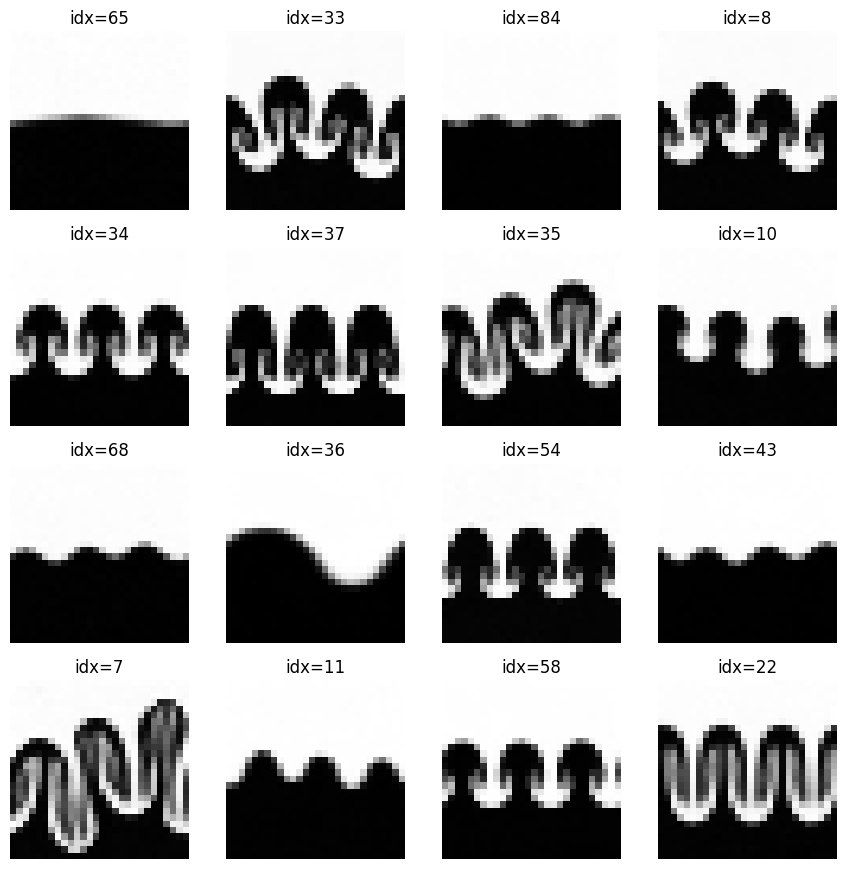

In [ ]:
# result_images = load_pt_results(ddpm, device="cpu", n_samples=16)
generated_dataset = torch.load(
    "generated/generated_dataset.pt",
    map_location="cpu",
    weights_only=True,
)
show_grid(generated_dataset, n=16, cols=4, save=True, save_path="generated.png")

## PhyFID

PhyFID apprend un encodeur sur `TRAIN_PT`, sauvegarde cet encodeur, puis compare `VAL_PT` et `result_set` dans l'espace de features appris. Le notebook cree `res/phyfid_encoder.pt` et `res/phyfid_val_stats.npz`; ensuite ces fichiers sont simplement recharges. En pratique ces fichiers ont été generé sur calculateur pour aller plus vite.

A noter qu'il en va de meme pour les data géneré, qui sont eux aussi re-charger dans le code et non re-calculer a chaque fois. Raison pour laquelle beaucoup de fonctions sont commentées.

In [ ]:
def generate_ddpm_dataset(model, n_samples=100):
    """
    Petite fonction separee pour produire un dataset avec le DDPM du notebook.

    Elle est volontairement hors de PhyFID: c'est une source possible d'images,
    mais la metrique peut comparer n'importe quel dataset deja disponible.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Generation des images avec le DDPM...")
    return load_pt_results(model, device=device, n_samples=n_samples)


In [36]:
from lib.PhyFID.utils import*
from lib.diffusion_lib.Logger import Logger

PHYFID_ENCODER = "out/phyfid_encoder.pt"
PHYFID_STATS = "out/phyfid_val_stats.npz"
PHYFID_LOG = "out/phyfid_training.log"
PHYFID_CSV = "out/phyfid_training.csv"

PHYFID_EPOCHS = 2
PHYFID_FEATURE_DIM = 32
PHYFID_BATCH_SIZE = 128

MAX_TRAIN_SIZE = 1024
MAX_EVAL_SIZE = 100

phyfid_logger = Logger(PHYFID_LOG, PHYFID_CSV, name="phyfid_logger")


Creation et entrainement du réseau phyFID

In [37]:
# build_phyfid_reference(
#     dataset_train_path=TRAIN_PT,
#     dataset_val_path=VAL_PT,
#     encoder_path=PHYFID_ENCODER,
#     stats_path=PHYFID_STATS,
#     train_epochs=PHYFID_EPOCHS,
#     feature_dim=PHYFID_FEATURE_DIM,
#     batch_size=PHYFID_BATCH_SIZE,
#     max_train_size=MAX_TRAIN_SIZE,
#     max_val_size=MAX_EVAL_SIZE,
#     logger=phyfid_logger,
# )


Verification de la metrique sur les jeux initiaux on compare tous les split du dataset au split de validation et on s'attend a de tres petite valeurs.

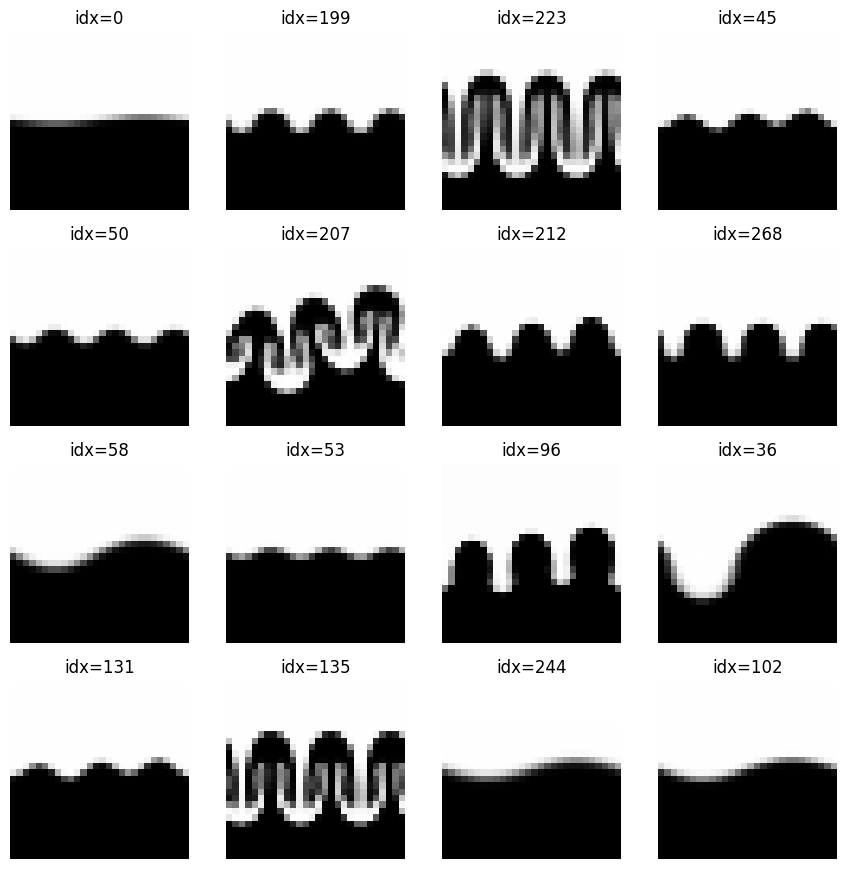

PhyFID val vs val: 0.6774, 
 PhyFID val vs test: 0.5560


In [38]:
val = load_pt_dataset(VAL_PT)
test = load_pt_dataset(TEST_PT)

show_grid(val, n=16, cols=4, save=False, save_path="val.png")

vv = compare_datasets(val[:100], val[100:200], PHYFID_ENCODER)
vt = compare_datasets(val[:100], test[:100], PHYFID_ENCODER)

print(f"PhyFID val vs val: {vv:.4f}, \n PhyFID val vs test: {vt:.4f}")

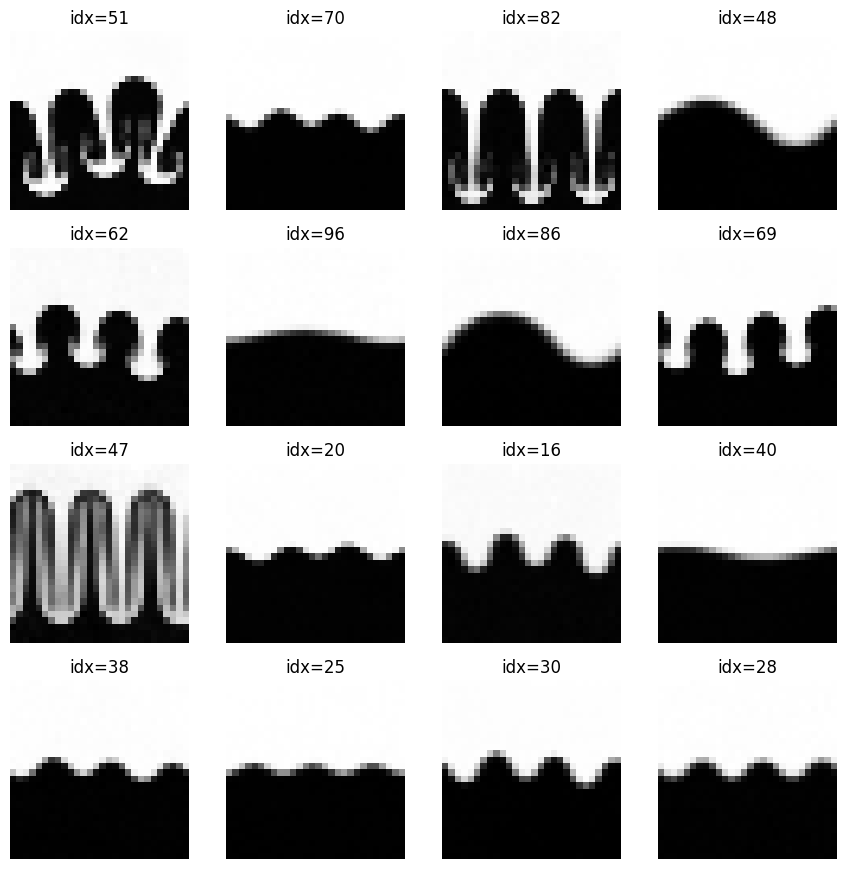

Calcul du score PhyFID...
PhyFID score: 27.0105
PhyFID val vs generated: 31.9369

saturation bas: 0.5759438872337341
saturation haut: 0.3869132697582245


In [39]:
# generated_dataset = generate_ddpm_dataset(ddpm, n_samples=MAX_EVAL_SIZE)
generated_dataset = torch.load(
    "generated/generated_dataset.pt",
    # "../data/RT28/processed/test.pt",
    map_location="cpu",
    weights_only=True,
)

show_grid(generated_dataset, n=16, cols=4, save=False, save_path="generated2.png")

# PHYFID_ENCODER = "phyfid_encoder.pt"
# PHYFID_STATS = "phyfid_val_stats.npz"

phyfid_score = evaluate_phyfid_dataset(
    generated_dataset,
    encoder_path=PHYFID_ENCODER,
    stats_path=PHYFID_STATS,
    batch_size=PHYFID_BATCH_SIZE,
)

vg = compare_datasets(val[:100], generated_dataset[:100], PHYFID_ENCODER)
print(f"PhyFID val vs generated: {vg:.4f}")
print()
print("saturation bas:", (generated_dataset <= 0).float().mean().item())
print("saturation haut:", (generated_dataset >= 1).float().mean().item())


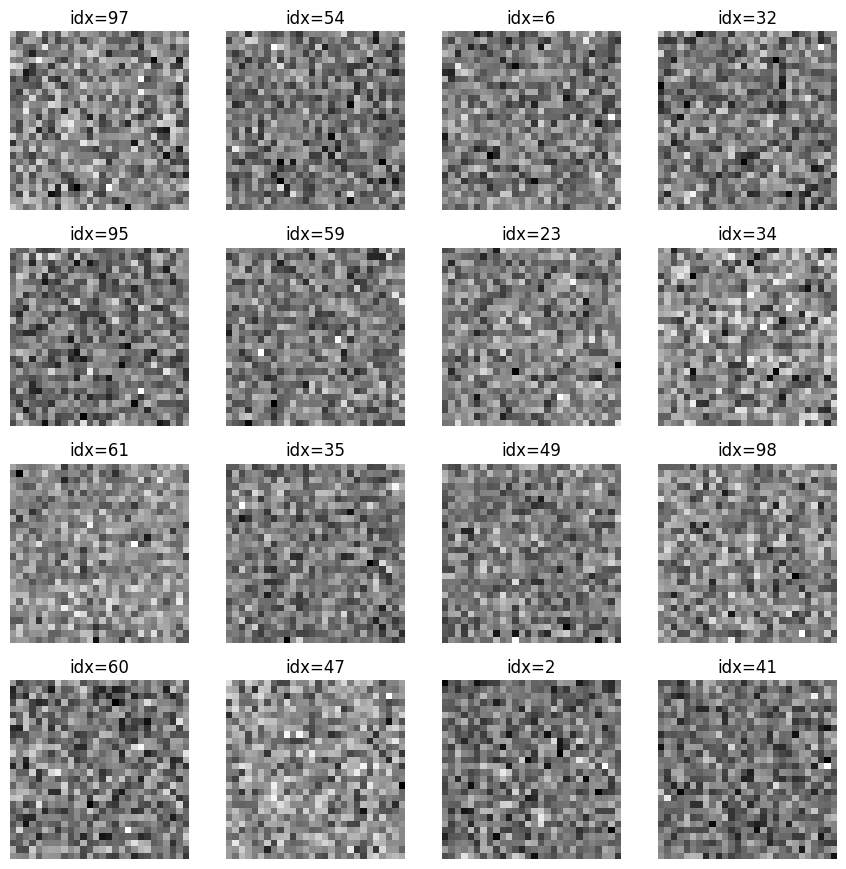

Calcul du score PhyFID...
PhyFID score: 59.3866
PhyFID val vs noise: 54.3189


In [40]:
# MODEL2_PT = "res/RT28-100OFF.pt" # Un faux modele juste pour produire du bruit

# ddpm2 = DDPM(
#     UNet(n_steps=N_STEPS, time_emb_dim=TIME_EMB_DIM),
#     n_steps=N_STEPS,
#     min_beta=MIN_BETA,
#     max_beta=MAX_BETA,
#     device=DEVICE,
# )

# generated_dataset2 = generate_ddpm_dataset(ddpm2, n_samples=MAX_EVAL_SIZE)

noise_dataset = torch.load(
    "generated/noise_dataset.pt",
    map_location="cpu",
    weights_only=True,
)

show_grid(noise_dataset, n=16, cols=4, save=False, save_path="generated2.png")

phyfid_score = evaluate_phyfid_dataset(
    noise_dataset,
    encoder_path=PHYFID_ENCODER,
    stats_path=PHYFID_STATS,
    batch_size=PHYFID_BATCH_SIZE,
)

vg2 = compare_datasets(val[:100], noise_dataset[:100], PHYFID_ENCODER)
print(f"PhyFID val vs noise: {vg2:.4f}")

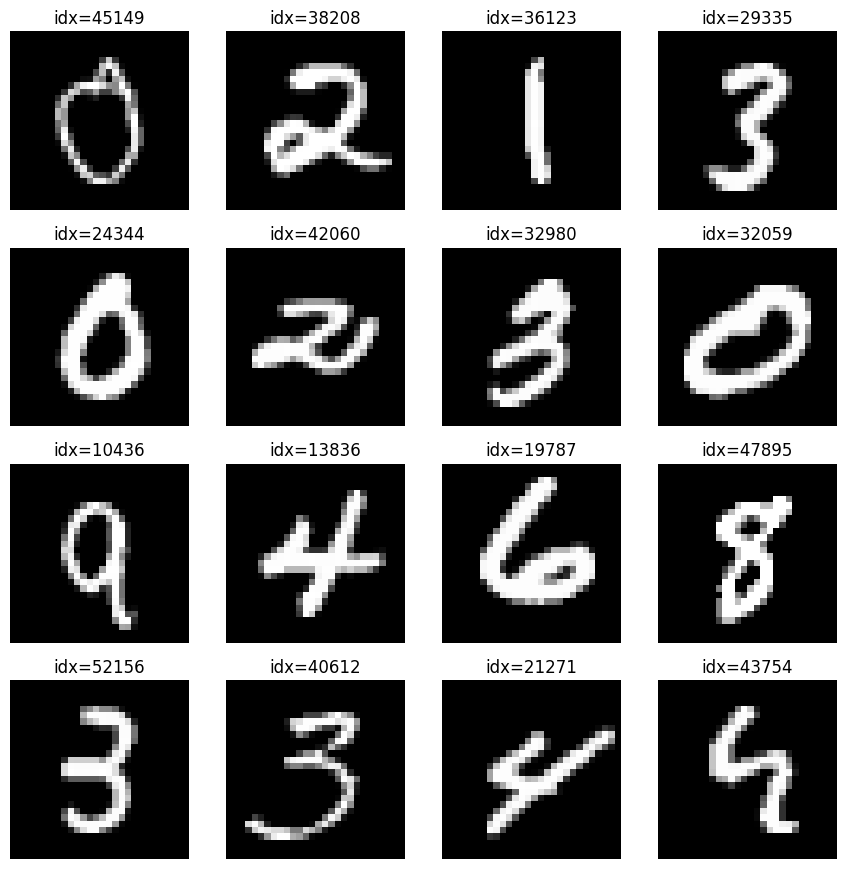

Calcul du score PhyFID...
PhyFID score: 16.3139
PhyFID val vs MNIST: 18.9019


In [41]:
MNIST = load_pt_dataset("../data/MNIST/processed/training.pt")
show_grid(MNIST, n=16, cols=4, save=False, save_path="mnist.png")

phyfid_score = evaluate_phyfid_dataset(
    MNIST,
    encoder_path=PHYFID_ENCODER,
    stats_path=PHYFID_STATS,
    batch_size=PHYFID_BATCH_SIZE,
)

vg2 = compare_datasets(val[:100], MNIST[:100], PHYFID_ENCODER)
print(f"PhyFID val vs MNIST: {vg2:.4f}")

## FID Inception standard

Cette baseline utilise directement l'InceptionV3 pre-entraine du depot local `lib/pytorch-fid-master`. Les cartes RT en niveaux de gris sont repetees sur trois canaux. Avec seulement 100 images, le bloc a 64 features est utilise pour eviter une covariance singuliere ; la FID standard a 2048 features demande plusieurs milliers d'images. Ces scores servent surtout a comparer l'ordre relatif des jeux de donnees.

In [42]:
# Le depot pytorch-fid utilise une structure src/: on ajoute ce dossier au chemin Python.
pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from pytorch_fid.fid_score import calculate_frechet_distance as pytorch_fid_distance
from pytorch_fid.inception import InceptionV3
from torch.nn.functional import adaptive_avg_pool2d
from torch.utils.data import DataLoader, TensorDataset


def prepare_images_for_fid(images):
    """Convertit NHW/NCHW/NHWC en RGB NCHW dans [0, 1]."""
    original_dtype = torch.as_tensor(images).dtype
    images = torch.as_tensor(images).detach().cpu().float()

    if images.ndim == 3:
        images = images.unsqueeze(1)
    elif images.ndim == 4 and images.shape[-1] in (1, 3) and images.shape[1] not in (1, 3):
        images = images.permute(0, 3, 1, 2)
    if images.ndim != 4:
        raise ValueError(f"Format non supporte: {tuple(images.shape)}")

    # Les datasets uint8 sont dans [0, 255]; les sorties DDPM sont attendues dans [-1, 1].
    if original_dtype == torch.uint8 or (images.min() >= 0 and images.max() > 1):
        images = images / 255.0
    elif images.min() < 0:
        images = (images + 1.0) / 2.0

    images = images.clamp(0.0, 1.0)
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    if images.shape[1] != 3:
        raise ValueError(f"FID attend 1 ou 3 canaux, recu: {images.shape[1]}")
    return images


def extract_fid_features(images, model, dims, batch_size, device):
    """Extrait les activations Inception depuis des tenseurs, sans fichiers PNG."""
    images = prepare_images_for_fid(images)
    loader = DataLoader(TensorDataset(images), batch_size=batch_size, shuffle=False)
    features = []

    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            prediction = model(batch.to(device))[0]
            if prediction.shape[-2:] != (1, 1):
                prediction = adaptive_avg_pool2d(prediction, output_size=(1, 1))
            features.append(prediction.flatten(1).cpu().numpy())

    return np.concatenate(features, axis=0)


def fid_from_features(reference_features, compared_features):
    """Calcule la FID officielle pytorch-fid depuis deux matrices de features."""
    reference_mu = np.mean(reference_features, axis=0)
    reference_sigma = np.cov(reference_features, rowvar=False)
    compared_mu = np.mean(compared_features, axis=0)
    compared_sigma = np.cov(compared_features, rowvar=False)
    return float(pytorch_fid_distance(
        reference_mu, reference_sigma, compared_mu, compared_sigma
    ))

In [43]:
# Les jeux generes ne contiennent que 100 images: toutes les comparaisons utilisent donc 100 images.
FID_N_IMAGES = min(100, len(generated_dataset), len(noise_dataset), len(MNIST), len(val) // 2)
# Avec 100 images, 2048 features donneraient une covariance singuliere.
# Remplacer par 2048 uniquement lorsque chaque dataset contient plusieurs milliers d'images.
FID_DIMS = 64
FID_BATCH_SIZE = 25
FID_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fid_block = InceptionV3.BLOCK_INDEX_BY_DIM[FID_DIMS]
fid_model = InceptionV3([fid_block]).to(FID_DEVICE)

# La reference val n'est encodee qu'une seule fois.
val_reference_features = extract_fid_features(
    val[:FID_N_IMAGES], fid_model, FID_DIMS, FID_BATCH_SIZE, FID_DEVICE
)

datasets_for_fid = {
    "val vs val": val[FID_N_IMAGES:2 * FID_N_IMAGES],
    "val vs generated": generated_dataset[:FID_N_IMAGES],
    "val vs noise": noise_dataset[:FID_N_IMAGES],
    "val vs MNIST": MNIST[:FID_N_IMAGES],
}

fid_scores = {}
for comparison_name, compared_images in datasets_for_fid.items():
    compared_features = extract_fid_features(
        compared_images, fid_model, FID_DIMS, FID_BATCH_SIZE, FID_DEVICE
    )
    fid_scores[comparison_name] = fid_from_features(
        val_reference_features, compared_features
    )

# Recalcule le PhyFID sur exactement les memes images pour une comparaison equitable.
phyfid_scores_same_samples = {
    comparison_name: compare_datasets(
        val[:FID_N_IMAGES], compared_images, PHYFID_ENCODER
    )
    for comparison_name, compared_images in datasets_for_fid.items()
}

print(f"Comparaison sur {FID_N_IMAGES} images (Inception: {FID_DIMS} features)")
print(f"{'Comparaison':<22} {'PhyFID':>12} {'FID Inception':>16}")
for comparison_name in datasets_for_fid:
    print(
        f"{comparison_name:<22} "
        f"{phyfid_scores_same_samples[comparison_name]:>12.4f} "
        f"{fid_scores[comparison_name]:>16.4f}"
    )

del fid_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Comparaison sur 100 images (Inception: 64 features)
Comparaison                  PhyFID    FID Inception
val vs val                   0.6774           0.0174
val vs generated            31.9369          24.4845
val vs noise                54.3189          24.2754
val vs MNIST                18.9019          14.2230
